# K-Means Clustering

- Bank Transactions

### Step 1: Import Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

### Step 2: Load and Inspect the Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')
# Update the path as needed
file_path = '/content/drive/MyDrive/Colab Notebooks/Unsupervised/bank_transactions.csv'
data = pd.read_csv(file_path)

#df = pd.read_csv('bank_marketing_part1_Data.csv')
data.head()

#data = pd.read_csv('customer_segmentation.csv')

#data.head()
#data = pd.read_csv('bank_transactions.csv')

Mounted at /content/drive


,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10-01-1994,F,JAMSHEDPUR,17819.05,02-08-2016,143207,25.0
1,T2,C2142763,04-04-1957,M,JHAJJAR,2270.69,02-08-2016,141858,27999.0
2,T3,C4417068,26-11-1996,F,MUMBAI,17874.44,02-08-2016,142712,459.0
3,T4,C5342380,14-09-1973,F,MUMBAI,866503.21,02-08-2016,142714,2060.0
4,T5,C9031234,24-03-1988,F,NAVI MUMBAI,6714.43,02-08-2016,181156,1762.5


In [3]:
# Explore the dataset
data.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10-01-1994,F,JAMSHEDPUR,17819.05,02-08-2016,143207,25.0
1,T2,C2142763,04-04-1957,M,JHAJJAR,2270.69,02-08-2016,141858,27999.0
2,T3,C4417068,26-11-1996,F,MUMBAI,17874.44,02-08-2016,142712,459.0
3,T4,C5342380,14-09-1973,F,MUMBAI,866503.21,02-08-2016,142714,2060.0
4,T5,C9031234,24-03-1988,F,NAVI MUMBAI,6714.43,02-08-2016,181156,1762.5


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            20000 non-null  object 
 1   CustomerID               20000 non-null  object 
 2   CustomerDOB              19928 non-null  object 
 3   CustGender               19989 non-null  object 
 4   CustLocation             19999 non-null  object 
 5   CustAccountBalance       19973 non-null  float64
 6   TransactionDate          20000 non-null  object 
 7   TransactionTime          20000 non-null  int64  
 8   TransactionAmount (INR)  20000 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 1.4+ MB


### Step 3: Data Preprocessing

In [5]:
# Convert the 'TransactionDate' column to datetime format
data['TransactionDate'] = pd.to_datetime(data['TransactionDate'], format='%d-%m-%Y')

In [6]:
data.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10-01-1994,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0
1,T2,C2142763,04-04-1957,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0
2,T3,C4417068,26-11-1996,F,MUMBAI,17874.44,2016-08-02,142712,459.0
3,T4,C5342380,14-09-1973,F,MUMBAI,866503.21,2016-08-02,142714,2060.0
4,T5,C9031234,24-03-1988,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5


In [7]:
# Drop rows with missing values
data.dropna(inplace=True)

In [8]:
# Select numeric features for clustering
numeric_features = data[['CustAccountBalance', 'TransactionAmount (INR)']]

In [9]:
data.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10-01-1994,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0
1,T2,C2142763,04-04-1957,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0
2,T3,C4417068,26-11-1996,F,MUMBAI,17874.44,2016-08-02,142712,459.0
3,T4,C5342380,14-09-1973,F,MUMBAI,866503.21,2016-08-02,142714,2060.0
4,T5,C9031234,24-03-1988,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5


In [10]:
# Standardize the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(numeric_features)

### Step 4: Exploratory Data Analysis (EDA)

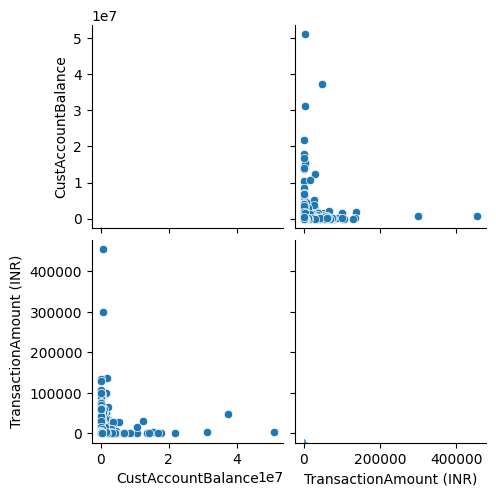

In [11]:
# Plot a pairplot to visualize relationships between numeric features
sns.pairplot(data[['CustAccountBalance', 'TransactionAmount (INR)']])
plt.show()

### Step 5: Finding the Optimal Number of Clusters (K)

In [ ]:
# Using the Elbow Method to find the optimal number of clusters (K)
wcss = []  # Within-Cluster Sum of Squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method to Find Optimal K')
plt.show()


In [13]:
# Perform K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
data['Cluster'] = kmeans.fit_predict(scaled_features)

In [ ]:
# Based on the Elbow Method, choose the optimal number of clusters (K)

# Visualize and Interpret the Clusters
plt.figure(figsize=(10, 6))
plt.scatter(data['CustAccountBalance'], data['TransactionAmount (INR)'], c=data['Cluster'], cmap='viridis')
plt.xlabel('CustAccountBalance')
plt.ylabel('TransactionAmount (INR)')
plt.title('K-means Clustering')
plt.show()

In [15]:
data.describe()

,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Cluster
count,1.988900e+04,19889,19889.000000,19889.000000,19889.000000
mean,1.200352e+05,2016-09-28 08:46:34.710644224,175436.701594,1710.874694,0.009151
min,0.000000e+00,2016-08-01 00:00:00,400.000000,0.000000,0.000000
25%,5.522240e+03,2016-09-25 00:00:00,152856.000000,150.000000,0.000000
50%,1.915149e+04,2016-09-26 00:00:00,184655.000000,419.520000,0.000000
75%,6.445509e+04,2016-09-27 00:00:00,203644.000000,1140.000000,0.000000
max,5.099967e+07,2016-10-21 00:00:00,235951.000000,455122.000000,2.000000
std,7.207429e+05,NaN,38276.312928,7195.339221,0.103813


In [16]:
data.head()
df=data[['CustAccountBalance','TransactionAmount (INR)','Cluster']]

In [17]:
df.groupby('Cluster').mean()

,CustAccountBalance,TransactionAmount (INR)
Cluster,,
0,1.024936e+05,1234.513489
1,2.758355e+05,64578.824527
2,1.911609e+07,7080.982353


In [18]:
df.groupby('Cluster').count()

,CustAccountBalance,TransactionAmount (INR)
Cluster,,
0,19724,19724
1,148,148
2,17,17
